In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import psutil
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
os.environ['KMP_DUPLICATE_LIB_OK']='True'


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


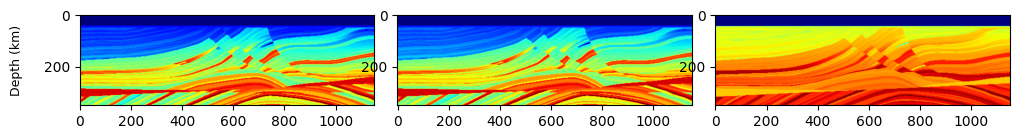

max values: tensor(4766.6040) tensor(2752.) tensor(2626.9998)
min values: tensor(1500.) tensor(800.) tensor(1009.)
model shape: torch.Size([352, 1150]) torch.Size([352, 1150]) torch.Size([352, 1150])


In [3]:
######### load data #########
dx = 10

vp_true = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy'))
vs_true = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy'))
rho_true = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy'))


submarine_deep = 43
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

17.387997
tensor(3927.0754, device='cuda:0') tensor(1847.8777, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2409.4448, device='cuda:0')


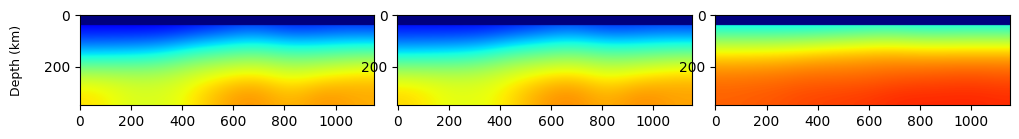

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

times = 6
if times != 0:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_n_times(vp_true, vs_true, rho_true, sigma, times, DEVICE)
else:
    vp_initial,vs_initial,rho_initial = gaussian_smooth_once(vp_true, vs_true, rho_true, sigma, DEVICE)

snr_vp = ComputeSNR(vp_initial.detach().cpu().numpy(), \
                  vp_true.detach().cpu().numpy())

print(snr_vp)
print(vp_initial.max(),vp_initial.min())
vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  

if times != 0:
    ##### save path
    vp_save_path = f'./rec/reconstruction_loss/EFWI_en/init_2/vp/'
    vs_save_path = f'./rec/reconstruction_loss/EFWI_en/init_2/vs/'
    rho_save_path = f'./rec/reconstruction_loss/EFWI_en/init_2/rho/'
    main_path = f'./log_data/log_data_loss/EFWI_en/init_2/'
else:
    vp_save_path = f'./rec/reconstruction_loss/EFWI_en/init_1/vp/'
    vs_save_path = f'./rec/reconstruction_loss/EFWI_en/init_1/vs/'
    rho_save_path = f'./rec/reconstruction_loss/EFWI_en/init_1/rho/'
    main_path = f'./log_data/log_data_loss/EFWI_en/init_1/'


if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)
    


In [6]:
Physics = Physics_deepwave                              
                           
model_shape = [vp_true.shape[0], vp_true.shape[1]]                                 
                                                                                       
DT = 0.006                                               
F_PEAK = 8                                              
DH = dx                                                  

inpa = {                                
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500

In [7]:
### load obs and src, src_loc, rec_loc
obs_file_vx = './obs_data/d_obs_vx_src.npy'
obs_file_vy = './obs_data/d_obs_vy_src.npy'
d_obs_vx = torch.tensor(np.load(obs_file_vx))
d_obs_vy = torch.tensor(np.load(obs_file_vy))

src_loc = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src     = torch.tensor(np.load('./sources/src.npy'))

### sum source
num_super_sources = 10
sources_per_super = 10
source_distribution = 'random'# ('random' 或 'uniform')

#### 1.
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc, 
                        receiver_locations  = rec_loc, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

#### 2
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)



Encoded observation data shape (vx): torch.Size([10, 2500, 1130])
Encoded observation data shape (vy): torch.Size([10, 2500, 1130])
Encoded source location shape: torch.Size([10, 10, 2])
Encoded receiver location shape: torch.Size([10, 1130, 2])
Encoded source function shape: torch.Size([10, 10, 2500])


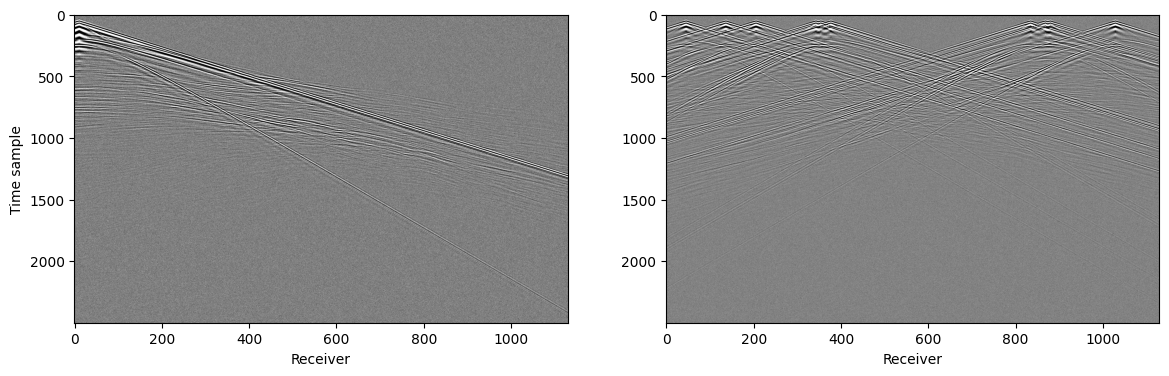

In [8]:

##### show these data
d_obs_vx_plot = d_obs_vx.squeeze(0)
d_obs_vx_en_plot = d_obs_vx_encode.squeeze(0)
vmin, vmax = torch.quantile(d_obs_vx_plot[1],
                            torch.tensor([0.01, 0.99]))
vsmin, vsmax = torch.quantile(d_obs_vx_en_plot[1],
                                 torch.tensor([0.01, 0.99]).to(DEVICE))


fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].imshow(d_obs_vx_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vmin, vmax=vmax)
ax[0].set_xlabel("Receiver")
ax[0].set_ylabel("Time sample")
ax[1].imshow(d_obs_vx_en_plot[1].cpu().detach().numpy(), aspect='auto', cmap='gray',vmin=vsmin, vmax=vsmax)
ax[1].set_xlabel("Receiver")
plt.subplots_adjust(hspace=0.6)  
plt.show()


In [9]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 6.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0}])

In [10]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2   
    
def get_gpu_memory():
    if torch.cuda.is_available():
        
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Iter 5 = loss: 10.2010,model loss: 268490632.00,time:6.91,snr_vp:18.195,snr_vs:18.163,snr_rho:22.626
Iter 10 = loss: 9.6038,model loss: 267717124.00,time:6.94,snr_vp:18.209,snr_vs:18.149,snr_rho:22.681
Iter 15 = loss: 8.9508,model loss: 266883064.00,time:6.94,snr_vp:18.221,snr_vs:18.128,snr_rho:22.738
Iter 20 = loss: 8.5502,model loss: 266725776.00,time:6.94,snr_vp:18.229,snr_vs:18.107,snr_rho:22.781


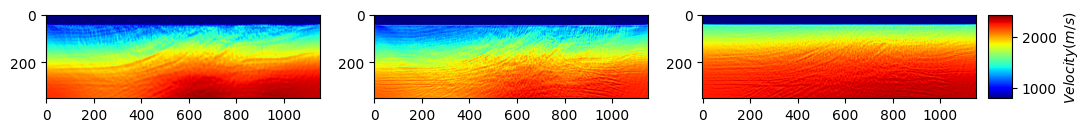

Iter 25 = loss: 8.3896,model loss: 266695956.00,time:6.94,snr_vp:18.236,snr_vs:18.094,snr_rho:22.796
Iter 30 = loss: 8.2541,model loss: 266587736.00,time:6.95,snr_vp:18.246,snr_vs:18.089,snr_rho:22.796
Iter 35 = loss: 8.1069,model loss: 266453012.00,time:7.08,snr_vp:18.257,snr_vs:18.087,snr_rho:22.785
Iter 40 = loss: 8.0133,model loss: 266240184.00,time:6.93,snr_vp:18.268,snr_vs:18.085,snr_rho:22.773


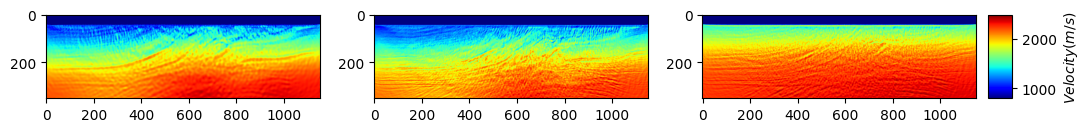

Iter 45 = loss: 7.9467,model loss: 266026424.00,time:6.93,snr_vp:18.279,snr_vs:18.081,snr_rho:22.757
Iter 50 = loss: 7.8968,model loss: 265858848.00,time:6.93,snr_vp:18.290,snr_vs:18.078,snr_rho:22.735
Iter 55 = loss: 7.8577,model loss: 265746628.00,time:6.92,snr_vp:18.299,snr_vs:18.074,snr_rho:22.708
Iter 60 = loss: 7.8247,model loss: 265774200.00,time:7.94,snr_vp:18.307,snr_vs:18.071,snr_rho:22.678


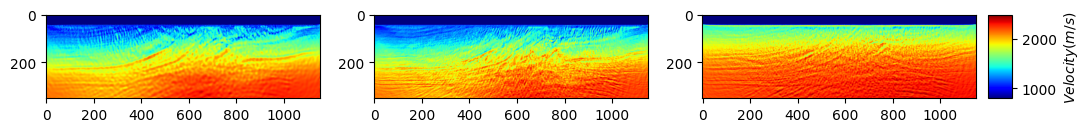

Iter 65 = loss: 7.7971,model loss: 265796424.00,time:7.94,snr_vp:18.314,snr_vs:18.067,snr_rho:22.647
Iter 70 = loss: 7.7735,model loss: 265880452.00,time:7.96,snr_vp:18.319,snr_vs:18.062,snr_rho:22.614
Iter 75 = loss: 7.7534,model loss: 265996876.00,time:7.96,snr_vp:18.323,snr_vs:18.057,snr_rho:22.580
Iter 80 = loss: 7.7361,model loss: 266138136.00,time:7.94,snr_vp:18.326,snr_vs:18.051,snr_rho:22.544


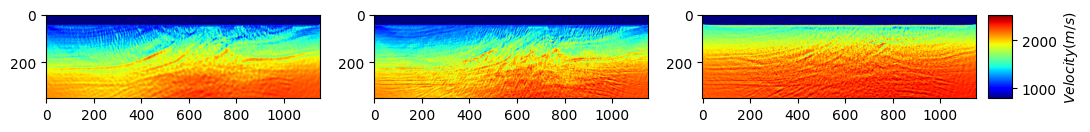

Iter 85 = loss: 7.7215,model loss: 266291912.00,time:7.94,snr_vp:18.329,snr_vs:18.044,snr_rho:22.508
Iter 90 = loss: 7.7090,model loss: 266452504.00,time:7.93,snr_vp:18.331,snr_vs:18.038,snr_rho:22.471
Iter 95 = loss: 7.6980,model loss: 266620484.00,time:7.94,snr_vp:18.334,snr_vs:18.032,snr_rho:22.433
Iter 100 = loss: 7.6883,model loss: 266796028.00,time:7.94,snr_vp:18.336,snr_vs:18.025,snr_rho:22.395


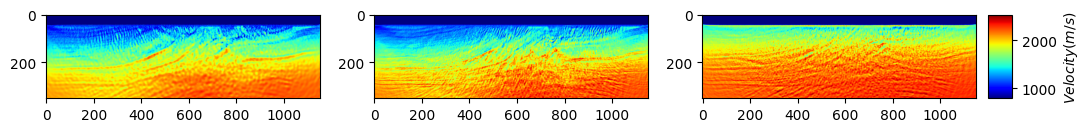

Iter 105 = loss: 7.6797,model loss: 266981244.00,time:7.93,snr_vp:18.337,snr_vs:18.019,snr_rho:22.357
Iter 110 = loss: 7.6720,model loss: 267174732.00,time:7.93,snr_vp:18.339,snr_vs:18.012,snr_rho:22.318
Iter 115 = loss: 7.6649,model loss: 267372632.00,time:7.94,snr_vp:18.340,snr_vs:18.006,snr_rho:22.280
Iter 120 = loss: 7.6585,model loss: 267574524.00,time:7.94,snr_vp:18.341,snr_vs:17.999,snr_rho:22.242


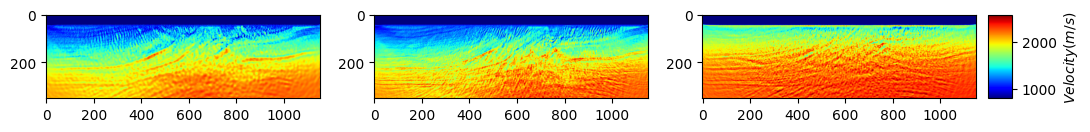

Iter 125 = loss: 7.6525,model loss: 267787908.00,time:7.94,snr_vp:18.341,snr_vs:17.992,snr_rho:22.204
Iter 130 = loss: 7.6469,model loss: 268020996.00,time:7.94,snr_vp:18.341,snr_vs:17.985,snr_rho:22.166
Iter 135 = loss: 7.6416,model loss: 268265048.00,time:7.94,snr_vp:18.341,snr_vs:17.978,snr_rho:22.129
Iter 140 = loss: 7.6367,model loss: 268514356.00,time:7.96,snr_vp:18.340,snr_vs:17.971,snr_rho:22.092


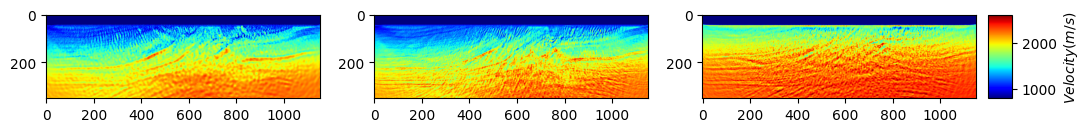

Iter 145 = loss: 7.6321,model loss: 268770092.00,time:7.94,snr_vp:18.339,snr_vs:17.963,snr_rho:22.055
Iter 150 = loss: 7.6277,model loss: 269037200.00,time:7.93,snr_vp:18.337,snr_vs:17.956,snr_rho:22.020
Iter 155 = loss: 7.6235,model loss: 269311828.00,time:7.93,snr_vp:18.335,snr_vs:17.948,snr_rho:21.984
Iter 160 = loss: 7.6196,model loss: 269591740.00,time:7.94,snr_vp:18.332,snr_vs:17.941,snr_rho:21.949


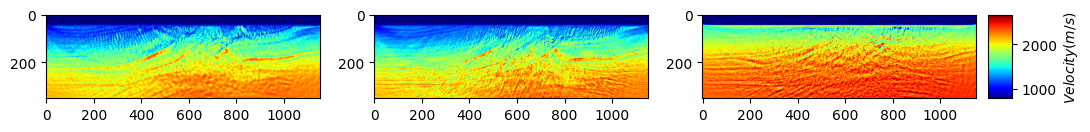

Iter 165 = loss: 7.6157,model loss: 269879200.00,time:7.94,snr_vp:18.329,snr_vs:17.933,snr_rho:21.915
Iter 170 = loss: 7.6120,model loss: 270172380.00,time:7.93,snr_vp:18.326,snr_vs:17.924,snr_rho:21.882
Iter 175 = loss: 7.6086,model loss: 270472468.00,time:7.95,snr_vp:18.322,snr_vs:17.916,snr_rho:21.848
Iter 180 = loss: 7.6052,model loss: 270781796.00,time:7.95,snr_vp:18.318,snr_vs:17.907,snr_rho:21.816


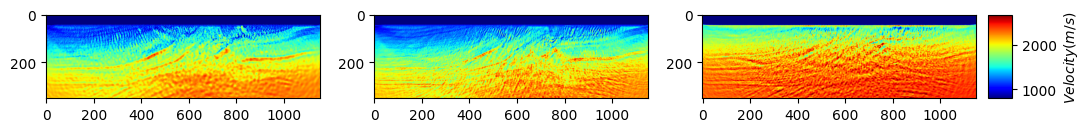

Iter 185 = loss: 7.6019,model loss: 271099456.00,time:7.94,snr_vp:18.313,snr_vs:17.899,snr_rho:21.784
Iter 190 = loss: 7.5988,model loss: 271423612.00,time:7.94,snr_vp:18.308,snr_vs:17.889,snr_rho:21.752
Iter 195 = loss: 7.5959,model loss: 271754912.00,time:7.95,snr_vp:18.302,snr_vs:17.880,snr_rho:21.721
Iter 200 = loss: 7.5929,model loss: 272093216.00,time:7.94,snr_vp:18.296,snr_vs:17.870,snr_rho:21.691


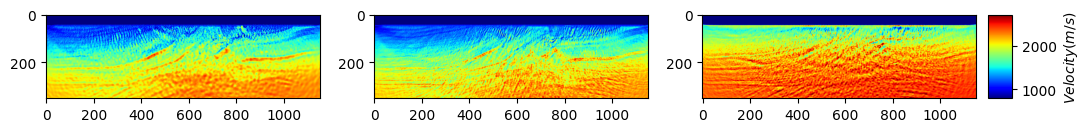

Iter 205 = loss: 7.5899,model loss: 272438216.00,time:8.06,snr_vp:18.290,snr_vs:17.861,snr_rho:21.661
Iter 210 = loss: 7.5872,model loss: 272792616.00,time:7.93,snr_vp:18.283,snr_vs:17.851,snr_rho:21.632
Iter 215 = loss: 7.5846,model loss: 273152676.00,time:8.00,snr_vp:18.276,snr_vs:17.840,snr_rho:21.603
Iter 220 = loss: 7.5818,model loss: 273517100.00,time:7.95,snr_vp:18.268,snr_vs:17.830,snr_rho:21.574


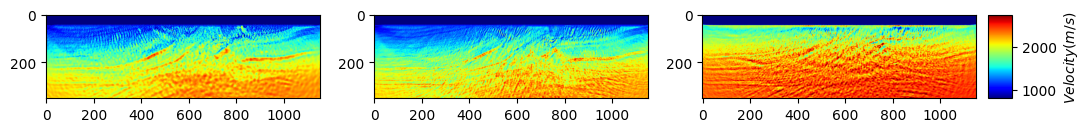

Iter 225 = loss: 7.5791,model loss: 273885484.00,time:7.94,snr_vp:18.260,snr_vs:17.820,snr_rho:21.546
Iter 230 = loss: 7.5766,model loss: 274263672.00,time:7.93,snr_vp:18.252,snr_vs:17.809,snr_rho:21.519
Iter 235 = loss: 7.5743,model loss: 274646088.00,time:7.94,snr_vp:18.244,snr_vs:17.799,snr_rho:21.492
Iter 240 = loss: 7.5717,model loss: 275034828.00,time:8.01,snr_vp:18.235,snr_vs:17.788,snr_rho:21.465


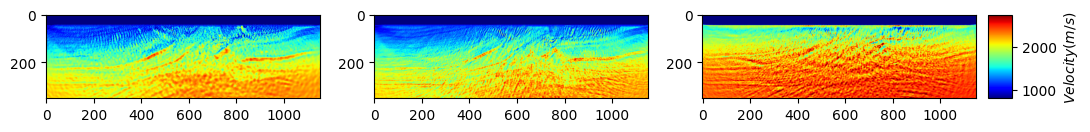

Iter 245 = loss: 7.5693,model loss: 275425296.00,time:7.96,snr_vp:18.226,snr_vs:17.777,snr_rho:21.439
Iter 250 = loss: 7.5669,model loss: 275817500.00,time:7.93,snr_vp:18.217,snr_vs:17.766,snr_rho:21.413
Iter 255 = loss: 7.5646,model loss: 276213656.00,time:7.93,snr_vp:18.207,snr_vs:17.755,snr_rho:21.388
Iter 260 = loss: 7.5623,model loss: 276616964.00,time:7.95,snr_vp:18.197,snr_vs:17.743,snr_rho:21.363


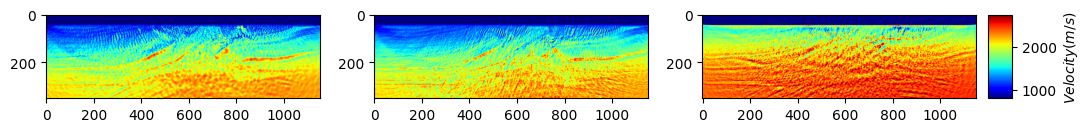

Iter 265 = loss: 7.5601,model loss: 277022696.00,time:7.94,snr_vp:18.187,snr_vs:17.732,snr_rho:21.338
Iter 270 = loss: 7.5578,model loss: 277436284.00,time:7.94,snr_vp:18.177,snr_vs:17.720,snr_rho:21.314
Iter 275 = loss: 7.5556,model loss: 277851460.00,time:7.94,snr_vp:18.166,snr_vs:17.708,snr_rho:21.290
Iter 280 = loss: 7.5533,model loss: 278269572.00,time:8.08,snr_vp:18.156,snr_vs:17.697,snr_rho:21.267


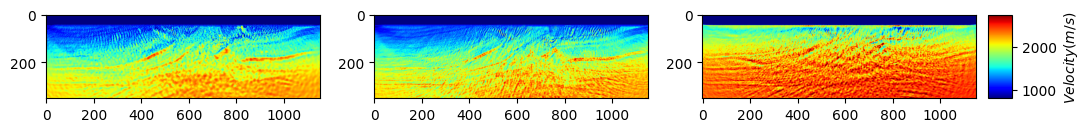

Iter 285 = loss: 7.5512,model loss: 278688108.00,time:7.94,snr_vp:18.145,snr_vs:17.684,snr_rho:21.244
Iter 290 = loss: 7.5490,model loss: 279110692.00,time:7.94,snr_vp:18.134,snr_vs:17.672,snr_rho:21.221
Iter 295 = loss: 7.5470,model loss: 279534184.00,time:7.94,snr_vp:18.122,snr_vs:17.660,snr_rho:21.198
Iter 300 = loss: 7.5449,model loss: 279959952.00,time:7.94,snr_vp:18.111,snr_vs:17.648,snr_rho:21.176


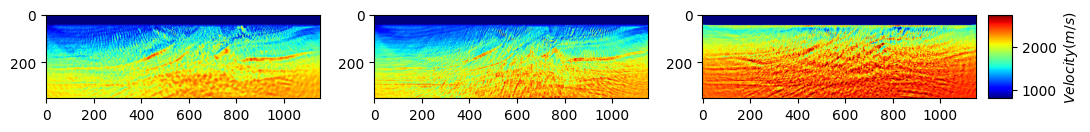

Running complete in 39m  37s


In [11]:
# Run optimisation/inversion

t_start = time.time()
mini_batches = 5
ITERATION = 300 

import time
t_start = time.time()

for iter in range(ITERATION):
    loss_data_minibatch = []
    
    time_each_bath_start = time.time()
    for batch in range(mini_batches):
   
        optimer.zero_grad()
    
        src_loc_batch = src_loc_encode[batch::mini_batches].to(DEVICE)
        rec_loc_batch = rec_loc_encode[batch::mini_batches].to(DEVICE)
        src_batch = src_encode[batch::mini_batches].to(DEVICE) ## for true source
            
        physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'] ,size=NT,src=src_batch,
                    src_loc=src_loc_batch, rec_loc=rec_loc_batch
                    )
        with torch.no_grad():
            vp[:submarine_deep,:] = submarine_vp
            vs[:submarine_deep,:] = submarine_vs
            rho[:submarine_deep,:] = submarine_rho
         
            vp[vp>vp_true.max()] = vp_true.max()
            vp[vp<vp_true.min()] = vp_true.min()
    
            vs[vs>vs_true.max()] = vs_true.max()
            vs[vs<vs_true.min()] = vs_true.min()
    
            rho[rho>rho_true.max()] = rho_true.max()
            rho[rho<rho_true.min()] = rho_true.min()
           
            vp = vp.requires_grad_(True)
            vs = vs.requires_grad_(True)
            rho = rho.requires_grad_(True)          
    
        vp = vp.to(DEVICE)
        vs = vs.to(DEVICE)
        rho = rho.to(DEVICE)
        

        taux_est = physics(vp,vs,rho) 
        taux_vx_est_filtered = taux_est[0].to(DEVICE)
        taux_vy_est_filtered = taux_est[1].to(DEVICE)
        
        taux_est_all = torch.cat((taux_vx_est_filtered,taux_vy_est_filtered),dim=1).to(DEVICE)
        #print(taux_est_all.shape)
        #print(taux_est_all)
        d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
        d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
        
        d_obs_filtered_all = torch.cat((d_obs_vx_filtered,d_obs_vy_filtered),dim=1).to(DEVICE)
        
        
        if loss_fn == 'l1':
            criteria = torch.nn.L1Loss(reduction='mean')
            loss_data = 1.0e9*criteria(taux_est_all, d_obs_filtered_all) 
        if loss_fn == 'l2':
            criteria = torch.nn.MSELoss(reduction='mean')
            loss_data = 1.0e12*criteria(taux_est_all, d_obs_filtered_all) 
        loss = loss_data
    
        loss.backward()
        
        optimer.step()

    all_loss_data.append(loss_data.detach().cpu().item())
    time_each_bath_end = time.time()
    time_each_iter.append(time_each_bath_end - time_each_bath_start)
   
        
    mem_now_cpu = get_cpu_memory()
    cpu_mem_log.append(mem_now_cpu)
    mem_now_gpu = get_gpu_memory()
    gpu_mem_log.append(mem_now_gpu)
    
    with torch.no_grad():
        all_loss_vx_model.append(
            criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
        )
    
        all_loss_vy_model.append(
            criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
            )
        all_loss_rho_model.append(
            criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
        )
        all_loss_model.append(
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()+ \
                criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
            )

    snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
              vp_true.detach().cpu().numpy())
    SNR_vp = np.append(SNR_vp, snr_vp)
    snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
              vs_true.detach().cpu().numpy())
    SNR_vs = np.append(SNR_vs, snr_vs)
    snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
              rho_true.detach().cpu().numpy())
    SNR_rho = np.append(SNR_rho, snr_rho)

    

    if (iter+1)%5 == 0:
        print(f"Iter {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.2f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")
    if (iter+1)%10==0:
        np.save(vp_save_path + 'recx_iter_%s.npy' % (iter + 1), vp.cpu().detach().numpy())
        np.save(vs_save_path + 'recx_iter_%s.npy' % (iter + 1), vs.cpu().detach().numpy())
        np.save(rho_save_path + 'recx_iter_%s.npy' % (iter + 1), rho.cpu().detach().numpy())
    if (iter+1)%20 == 0:
    
        fig, ax = plt.subplots(1,3,figsize=(12, 6))
        im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        points = ax[1].get_position().get_points()
        dy = points[1, 1] - points[0, 1]
        cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
        cax.yaxis.set_ticks_position("right")
        cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                        extend="neither", label="$Velocity (m/s)$"
                        )
        plt.show()
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [12]:

with torch.no_grad():
    
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')
    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')
